<a href="https://colab.research.google.com/github/FrankArcosAnselmo/mI_lab01_Fa/blob/develop/LABORATORIO_10_ARCOS_FRANK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

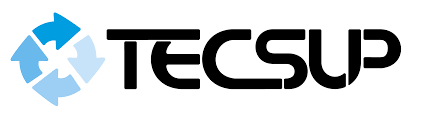

# LABORATORIO 10
## NOMBRE: ARCOS ANSELMO FRANK FERNANDO RODOLFO

A) Realice el preprocesamiento de la información que incluya el análisis de datos faltantes,
tratamiento de outliers a nivel univariado y multivariado, escalamiento de datos para las
variables numéricas y dumización para las variables categóricas. Además, elimine las variables
‘fabricante’, ‘modelo’, ‘transmision’, ‘traccion’, ‘clase’, ‘combustible’ y ‘consumo’.

In [ ]:
import pandas as pd

vehiculos = pd.read_csv('/content/drive/MyDrive/Ciclo II/vehículos.csv', sep=',', on_bad_lines='skip')
vehiculos.info()
vehiculos.describe()
vehiculos.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36791 entries, 0 to 36790
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fabricante            36791 non-null  object 
 1   modelo                36791 non-null  object 
 2   year                  36791 non-null  int64  
 3   desplazamiento        36789 non-null  float64
 4   cilindros             36788 non-null  float64
 5   transmision           36789 non-null  object 
 6   traccion              36002 non-null  object 
 7   clase                 36791 non-null  object 
 8   combustible           36791 non-null  object 
 9   consumo               36791 non-null  int64  
 10  co2                   36791 non-null  float64
 11  clase_tipo            36791 non-null  object 
 12  traccion_tipo         36791 non-null  object 
 13  transmision_tipo      36791 non-null  object 
 14  combustible_tipo      36791 non-null  object 
 15  tamano_motor_tipo  

,fabricante,modelo,year,desplazamiento,cilindros,transmision,traccion,clase,combustible,consumo,co2,clase_tipo,traccion_tipo,transmision_tipo,combustible_tipo,tamano_motor_tipo,consumo_tipo,co2_tipo,consumo_litros_milla
0,AM General,DJ Po Vehicle 2WD,1984,2.5,4.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,17,522.764706,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.222671
1,AM General,FJ8c Post Office,1984,4.2,6.0,Automatic 3-spd,2-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
2,AM General,Post Office DJ5 2WD,1985,2.5,4.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,16,555.437500,Vehículos Especiales,dos,Automatica,Normal,pequeño,alto,alto,0.236588
3,AM General,Post Office DJ8 2WD,1985,4.2,6.0,Automatic 3-spd,Rear-Wheel Drive,Special Purpose Vehicle 2WD,Regular,13,683.615385,Vehículos Especiales,dos,Automatica,Normal,grande,muy alto,muy alto,0.291185
4,ASC Incorporated,GNX,1987,3.8,6.0,Automatic 4-spd,Rear-Wheel Drive,Midsize Cars,Premium,16,555.437500,Coches Medianos,dos,Automatica,Premium,grande,alto,alto,0.236588


In [ ]:
vehiculos = vehiculos.drop(columns=['fabricante', 'modelo', 'transmision', 'traccion', 'clase', 'combustible', 'consumo'])


In [ ]:
# Revisar valores faltantes
vehiculos.isnull().sum()

# Opción: eliminar o imputar
vehiculos = vehiculos.dropna()  # Alternativa: imputar si se desea


In [ ]:
import numpy as np

def eliminar_outliers(df, columnas):
    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        df = df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]
    return df

columnas_numericas = vehiculos.select_dtypes(include=np.number).columns
vehiculos = eliminar_outliers(vehiculos, columnas_numericas)


In [ ]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.01, random_state=42)
outliers = iso.fit_predict(vehiculos[columnas_numericas])
vehiculos = vehiculos[outliers == 1]


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
vehiculos[columnas_numericas] = scaler.fit_transform(vehiculos[columnas_numericas])


In [ ]:
vehiculos = pd.get_dummies(vehiculos, drop_first=True)


B) Aplique un análisis de conglomerados no jerárquico por medio del método k-means y utilice el
método del codo para determinar la cantidad de clusters adecuados. Compare los
conglomerados formados y comente sobre las características que definen a estos

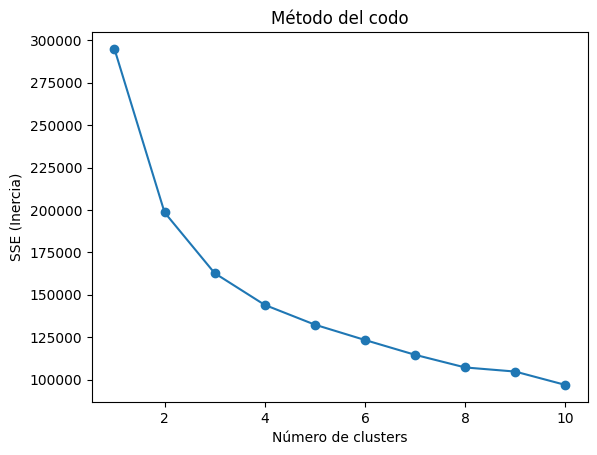

In [13]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

sse = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(vehiculos)
    sse.append(kmeans.inertia_)

plt.plot(range(1, 11), sse, marker='o')
plt.xlabel('Número de clusters')
plt.ylabel('SSE (Inercia)')
plt.title('Método del codo')
plt.show()


In [14]:
kmeans = KMeans(n_clusters=3, random_state=42)  # Cambiar a la cantidad óptima encontrada
vehiculos['cluster'] = kmeans.fit_predict(vehiculos)

# Comparar clusters: medias por grupo
vehiculos.groupby('cluster').mean()


,year,desplazamiento,cilindros,co2,consumo_litros_milla,clase_tipo_Coche Familiar,clase_tipo_Coches Grandes,clase_tipo_Coches Medianos,clase_tipo_Coches pequeños,clase_tipo_Deportivos,...,tamano_motor_tipo_muy pequeño,tamano_motor_tipo_pequeño,consumo_tipo_bajo,consumo_tipo_moderado,consumo_tipo_muy alto,consumo_tipo_muy bajo,co2_tipo_bajo,co2_tipo_moderado,co2_tipo_muy alto,co2_tipo_muy bajo
cluster,,,,,,,,,,,,,,,,,,,,,
0,0.045508,-0.033090,0.109121,0.065415,0.074258,0.070422,0.076817,0.157631,0.318241,0.153924,...,0.035029,0.171584,0.192006,0.663881,0.002180,0.009884,0.178198,0.679070,0.00218,0.002035
1,0.051082,-0.935783,-0.998838,-1.003252,-1.001061,0.119488,0.011708,0.123308,0.551856,0.117496,...,0.622187,0.352404,0.394171,0.002574,0.000000,0.602425,0.404966,0.005729,0.00000,0.588475
2,-0.142571,1.346612,1.209084,1.284260,1.267254,0.014127,0.053750,0.048926,0.124727,0.192604,...,0.000000,0.003790,0.011255,0.104743,0.553578,0.000000,0.005743,0.080854,0.59412,0.000000


C) Calcule las principales medidas de evaluación interna e interprete los resultados obtenidos.
También, calcule las principales medidas de evaluación externa tomando una cantidad de
clusters de 8 y de referencia a la variable ‘clase_tipo’.

In [15]:
from sklearn.metrics import silhouette_score

score = silhouette_score(vehiculos.drop(columns='cluster'), vehiculos['cluster'])
print(f'Silhouette Score: {score:.4f}')


Silhouette Score: 0.2281


In [17]:
# Asumimos que ‘clase_tipo’ sigue en el dataset original antes de ser eliminada
vehiculos_ext = pd.read_csv('/content/drive/MyDrive/Ciclo II/vehículos.csv', sep=',', on_bad_lines='skip')
vehiculos_ext = pd.concat([vehiculos_ext[['clase_tipo']], vehiculos], axis=1).dropna()

# Aplicar K-means con 8 clusters
kmeans_8 = KMeans(n_clusters=8, random_state=42)
vehiculos_ext['cluster_8'] = kmeans_8.fit_predict(vehiculos_ext.drop(columns=['clase_tipo', 'cluster']))

from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(vehiculos_ext['clase_tipo'], vehiculos_ext['cluster_8'])
nmi = normalized_mutual_info_score(vehiculos_ext['clase_tipo'], vehiculos_ext['cluster_8'])

print(f'Adjusted Rand Index: {ari:.4f}')
print(f'Normalized Mutual Info: {nmi:.4f}')


Adjusted Rand Index: 0.0940
Normalized Mutual Info: 0.1438
